In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import itertools
import jinja2
import json
import logging
import scipy.stats

from IPython.display import HTML

logging.basicConfig(level=logging.INFO)

In [2]:
from pathlib import Path

if Path.cwd().name == "notebooks":
    %cd ..
from common.shared_analysis import *

In [3]:
# maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0.csv

In [4]:
# Which experiments cover the different parameterizations of the equity efficiency model best?

dir = "data/scenarios"
for file in os.listdir(dir):
    if ".csv" not in file:
        continue
    df = explode_df(pd.read_csv(dir + "/" + file), num_scenarios=4)
    print(file)
    for i in range(0, 11):
        if "scenario_fehr" in df:
            del df["scenario_fehr"]
        df = add_fehr(df, alpha=i / 10)
        n = len(test(df, between=("scenario_nbs", "scenario_fehr")))
        print(f"{i:2d}: {n} / {len(df)}")
    print()

# Answer: The (random) scenarios with action range 1 to 101

# maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101_action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_num-scenarios=4_sample-size=68.0.csv

maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=3_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=200.0_first_1.csv
 0: 1 / 4
 1: 0 / 4
 2: 0 / 4
 3: 0 / 4
 4: 1 / 4
 5: 0 / 4
 6: 2 / 4
 7: 2 / 4
 8: 2 / 4
 9: 2 / 4
10: 2 / 4

maximize=True_num-agents=3_belief-steps=10_belief-range=[0.1,0.9]_action-steps=101_action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_disagrees-only=False_num-scenarios=4_sample-size=68.0.csv
 0: 68 / 136
 1: 56 / 136
 2: 52 / 136
 3: 44 / 136
 4: 48 / 136
 5: 48 / 136
 6: 72 / 136
 7: 84 / 136
 8: 100 / 136
 9: 108 / 136
10: 108 / 136

maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=3_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0.csv
 0: 72 / 136
 1: 32 / 136
 2: 0 / 136
 3: 0 / 136
 4: 8 / 136
 5: 24 / 136
 6: 24 / 136
 7: 32 / 136
 8: 32 / 136
 9: 32 / 136
10: 24 / 136

maximize=True_num-agents=3_belief-steps

In [5]:
num_scenarios = 4
# NB this is just the pilot
# scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101\
# _action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']\
# _num-scenarios=4_sample-size=10.0" # want this file but with 68.0 on the end -- need to run another exp. for it, tho

scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=3\
_action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0"  ## original scenario

# random_scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101\
# _action-range=1,101_action-function-log=False_num-scenarios=4_sample-size=68.0"

# scenario = "maximize=True_num-agents=3_belief-steps=10_belief-range=[0.1,0.9]_action-steps=101\
# _action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_disagrees-only=False\
# _num-scenarios=4_sample-size=68.0" ## group size scenario

dfs = mturk_dfs(
    scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)

condition = "Area"

# We only have the `none` scenario here
df_none = None
for df in dfs:
    if df.name == condition:
        df_none = df
        break

Area: 0/0.00 failed checks out of 102
Both: 0/0.00 failed checks out of 102
None: 0/0.00 failed checks out of 102
Volume: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.1 and std 3.9 and wage $29.4


In [6]:
normalize = True
values = {}
table = {}
lower_errors = {}
upper_errors = {}
between = ("scenario_nbs", "scenario_fehr")
names = {"scenario_nbs": "Nash Product", "scenario_fehr": "Inequality Sum"}

proportion_disagree = []

for function in between:
    values[function] = []
    lower_errors[function] = []
    upper_errors[function] = []

values["both"] = []
lower_errors["both"] = []
upper_errors["both"] = []


x = np.arange(0, 1.1, 0.1)

for i in x:
    if "scenario_fehr" in df:
        del df["scenario_fehr"]
    df = add_fehr(df, alpha=i)
    n = len(df)
    agreements = not_null_ties(control(df, between))
    disagreements = test(df, between)

    table[f"{i:.1f}"] = {}
    table[f"{i:.1f}"]["# disagreements"] = len(disagreements)
    table[f"{i:.1f}"]["# agreements"] = len(agreements)
    table[f"{i:.1f}"][
        "ratio"
    ] = f"{len(agreements) / len(disagreements) if len(disagreements) > 0 else 0:.2f}"

    proportion_disagree.append(len(disagreements) / len(agreements))

    for function in between:
        datum, (low, high) = function_success(
            disagreements, normalize=normalize, function=function
        )
        values[function].append(datum)
        lower_errors[function].append(low)
        upper_errors[function].append(high)

    function = "both"
    datum, (low, high) = control_success(
        agreements, normalize=normalize, between=between
    )
    values[function].append(datum)
    lower_errors[function].append(low)
    upper_errors[function].append(high)

In [7]:
print(pd.DataFrame(table).T.to_latex())

\begin{tabular}{llll}
\toprule
 & # disagreements & # agreements & ratio \\
\midrule
0.0 & 216 & 120 & 0.56 \\
0.1 & 96 & 240 & 2.50 \\
0.2 & 0 & 336 & 0.00 \\
0.3 & 0 & 336 & 0.00 \\
0.4 & 24 & 312 & 13.00 \\
0.5 & 72 & 264 & 3.67 \\
0.6 & 72 & 264 & 3.67 \\
0.7 & 96 & 240 & 2.50 \\
0.8 & 96 & 240 & 2.50 \\
0.9 & 96 & 240 & 2.50 \\
1.0 & 72 & 120 & 1.67 \\
\bottomrule
\end{tabular}



In [35]:
## TODO: Make a table of the above but with the total number of scenarios!

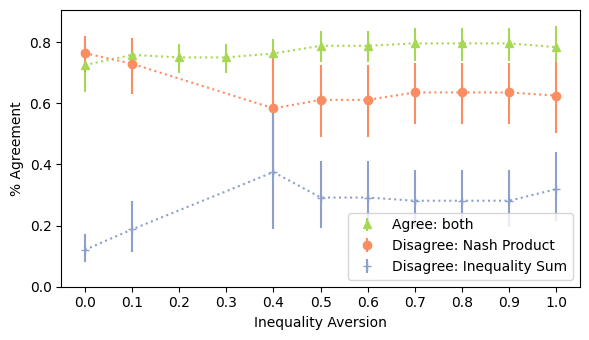

In [37]:
with plt.rc_context({"font.size": 10}):
    fig, ax1 = plt.subplots(figsize=(6, 3.5))

    # Plotting lines with error bars and dotted line
    # for function in between:
    #     ax1.errorbar(x, values[function], yerr=[lower_errors[function], upper_errors[function]],
    #                  fmt='o', color=AGGREGATION_TO_COLOR[function], label="Disagree: " + names[function])
    #     ax1.plot(x, values[function], linestyle=':', color=AGGREGATION_TO_COLOR[function])

    # Agreement cases
    function = "both"
    ax1.errorbar(
        x,
        values[function],
        yerr=[lower_errors[function], upper_errors[function]],
        fmt="^",
        color=CONDITION_TO_COLOR[condition],
        label="Agree: both",
    )
    ax1.plot(x, values[function], linestyle=":", color=CONDITION_TO_COLOR[condition])

    x_cutoff = np.concatenate((x[:2], x[4:]))
    symbols = ["o", "+"]
    for function, symbol in zip(["scenario_nbs", "scenario_fehr"], symbols):
        # Plot the dots with error bars
        ax1.errorbar(
            x_cutoff,
            values[function][:2] + values[function][4:],
            yerr=[
                lower_errors[function][:2] + lower_errors[function][4:],
                upper_errors[function][:2] + upper_errors[function][4:],
            ],
            fmt=symbol,
            color=AGGREGATION_TO_COLOR[function],
            label="Disagree: " + names[function],
        )
        # Plot the lines without the masked ranges
        ax1.plot(
            x_cutoff,
            values[function][:2] + values[function][4:],
            linestyle=":",
            color=AGGREGATION_TO_COLOR[function],
        )

    # Adding labels and title
    ax1.set_xlabel("Inequality Aversion")
    ax1.set_ylabel("% Agreement")
    # ax1.set_title('Comparing the Nash Product and Parameterized Inequality Sum')
    ax1.legend(loc="lower right")

    # Setting x-axis ticks at every tenth
    ax1.set_xticks(x)
    ax1.set_ylim(0, 0.905)

    # # Create a secondary y-axis
    # ax2 = ax1.twinx()

    # # Sample data for the secondary y-axis

    # # Plotting the secondary y-axis data
    # ax2.plot(x, proportion_disagree, 'o-', color='lightgrey', label='# disagree /\n# agree')
    # ax2.set_ylabel('Ratio')
    # ax2.set_ylim(0, 1.8)
    # ax2.legend(loc='upper right')

    # Display the plot
    fig.tight_layout()

    save_fig(fig, name="nash_inequality_aversion_area")
    plt.show()

None: 0/0.00 failed checks out of 102
Total workers failed checks: 0
total time in minutes: mean 6.7 and std 5.6 and wage $26.9


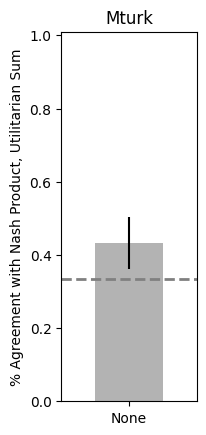

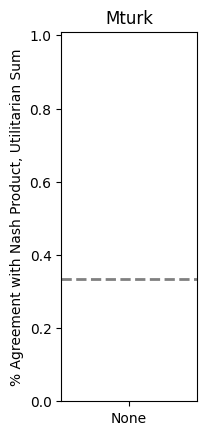

In [10]:
# first_pilot_scenario = "maximize=True_num-agents=3_belief-steps=1_belief-range=3,3_action-steps=101_action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_num-scenarios=4_sample-size=10.0"
# scenario = "maximize=True_num-agents=3_belief-steps=9_belief-range=[0.1,0.9]_action-steps=101_action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_disagrees-only=True_num-scenarios=4_sample-size=10.0"
# This is the group size changing one
scenario = "maximize=True_num-agents=3_belief-steps=10_belief-range=[0.1,0.9]_action-steps=101\
_action-range=1,101_action-function-log=False_prevent-ties=True_agg-functions=['nash','fehr','util']_disagrees-only=False\
_num-scenarios=4_sample-size=68.0"

dfs = mturk_dfs(
    scenario,
    num_scenarios=num_scenarios,
    delete_user_fail_check=True,
    aggregate_responses=False,
    plot=False,
)

dfs = sorted(dfs, key=lambda x: CONDITION_ORDER.index(x.name))

fig = plot_control_binomial(dfs, "Mturk")

fig = plot_control_binomial(dfs, "Mturk", blank=True)

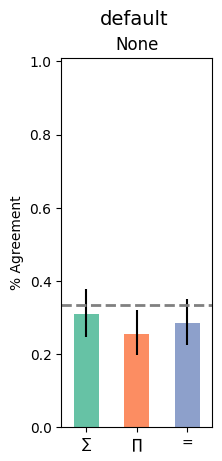

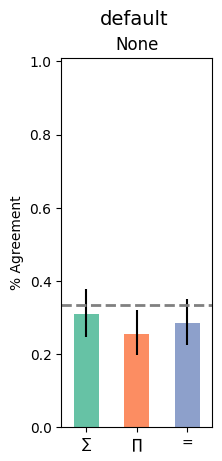

In [11]:
plot_conditions_binomial(
    dfs=dfs,
    selector=test,
    title="default",
    between=("scenario_mec", "scenario_nbs", "scenario_fehr"),
)

### 